# **Annotation of artefacts**

## Introduction

This chapter will show how artefacts can be identified and then annotated. The annotations will be encoded in the FIF data file. Sections or trials will not be rejected at this stage; rather, the annotations may be used later. For instance, they can be used to reject trials with eyeblinks or muscle contractions depending on their relevance for the analysis.


## Preparations

### Import the necessary modules

Below are the required Python modules


In [1]:
import os.path as op
import warnings
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne_bids import BIDSPath, read_raw_bids
from mne.preprocessing import annotate_muscle_zscore

### File overview

This section reads the HFC-corrected recording produced in the previous section:
```
<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
```
and writes the annotated data and a separate annotations file:
```
<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.fif
<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.csv
```

### Loading the BIDS data

Specify the parameters allowing for defining the path for the BIDS path


In [2]:
subject = '01'
session = '01'
task = 'SpAtt'
run = '01'
meg_suffix = 'meg'
hfc_suffix = 'hfc_raw'
ann_suffix = 'ann_raw'

#data_path='E:/Data/Cerca'
data_path = '/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data'

bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root = op.join(bids_root, "derivatives/preprocessing")

bids_path = BIDSPath(subject=subject, session=session, datatype='meg',
            task=task, run=run, suffix=hfc_suffix, 
            root=deriv_root, extension='.fif', check=False)

deriv_fname = bids_path.basename.replace(hfc_suffix, ann_suffix) # fif output filename
deriv_fname_fif = op.join(bids_path.directory, deriv_fname)

deriv_fname_csv = deriv_fname_fif.replace('.fif', '.csv') # csv output filename

print(bids_path)
print(deriv_fname_fif)
print(deriv_fname_csv)

/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.fif
/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.csv


Read the raw data

In [3]:
# The sidecar .tsv/.json files live with the raw BIDS data, not in derivatives,
# so read_raw_bids warns it cannot find them. The channel info and annotations are
# already stored in the .fif, so these warnings are harmless and are silenced here.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    raw = read_raw_bids(bids_path=bids_path, extra_params={'preload': True}, verbose=True)

Opening raw data file /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif...
    Read a total of 8 projection items:
        HFC: l=1 m=-1 (1 x 170) active
        HFC: l=1 m=0 (1 x 170) active
        HFC: l=1 m=1 (1 x 170) active
        HFC: l=2 m=-2 (1 x 170) active
        HFC: l=2 m=-1 (1 x 170) active
        HFC: l=2 m=0 (1 x 170) active
        HFC: l=2 m=1 (1 x 170) active
        HFC: l=2 m=2 (1 x 170) active
    Range : 0 ... 1241951 =      0.000 ...  1655.935 secs
Ready.
Reading 0 ... 1241951  =      0.000 ...  1655.935 secs...


`read_raw_bids` would otherwise warn that no `events.tsv`, `channels.tsv`, `meg.json` or `participants.tsv` were found. This is expected: the file being read lives in the `derivatives` folder, which stores processed data and does not carry the full set of BIDS sidecar files that accompany the raw recording. The channel information and annotations are already stored inside the `.fif`, so the warnings are harmless — the cell above suppresses them with a `warnings.catch_warnings()` block.

## Detecting eye-blink artefacts in the OPM sensors

Eye-blink artefacts can be detected directly from the OPM sensors, without relying on a separate EOG recording as is typical in EEG and conventional MEG studies. Here, blinks are identified from the difference between two frontal OPM sensors placed close to the eyes:

- F9 A4 Z
- F10 B3 Z

The difference between these two frontal channels approximates a bipolar EOG signal. This differential signal is stored in a newly created EOG channel named `OCC`, which then acts as a surrogate ocular channel.

The signal is band-pass filtered to 1–10 Hz to isolate the frequency components associated with ocular artefacts. A blink is flagged whenever the filtered signal exceeds a fixed threshold, here set to `0.3e-11` T (= 3000 fT) by visual inspection of the trace below. Each detected blink is annotated over a 500 ms window, from 250 ms before to 250 ms after the threshold crossing.

To construct the ocular signal, write:

In [4]:
print(raw.ch_names)

['F1 A1 Z', 'F1 A1 Y', 'F1 A1 X', 'F3 A3 Z', 'F3 A3 Y', 'F3 A3 X', 'F9 C8 Z', 'F9 C8 Y', 'F9 C8 X', 'F11 C7 Z', 'F11 C7 Y', 'F11 C7 X', 'C1 A7 Z', 'C1 A7 Y', 'C1 A7 X', 'C3 C4 Z', 'C3 C4 Y', 'C3 C4 X', 'C5 C2 Z', 'C5 C2 Y', 'C5 C2 X', 'C7 E4 Z', 'C7 E4 Y', 'C7 E4 X', 'P1 C1 Z', 'P1 C1 Y', 'P1 C1 X', 'P3 E3 Z', 'P3 E3 Y', 'P3 E3 X', 'P5 E7 Z', 'P5 E7 Y', 'P5 E7 X', 'P7 E6 Z', 'P7 E6 Y', 'P7 E6 X', 'P9 G1 Z', 'P9 G1 Y', 'P9 G1 X', 'P11 E1 Z', 'P11 E1 Y', 'P11 E1 X', 'O1 G2 Z', 'O1 G2 Y', 'O1 G2 X', 'O3 G5 Z', 'O3 G5 Y', 'O3 G5 X', 'O5 G3 Z', 'O5 G3 Y', 'O5 G3 X', 'O7 H5 Z', 'O7 H5 Y', 'O7 H5 X', 'O9 G7 Z', 'O9 G7 Y', 'O9 G7 X', 'T1 C6 Z', 'T1 C6 Y', 'T1 C6 X', 'T3 C3 Z', 'T3 C3 Y', 'T3 C3 X', 'T5 C5 Z', 'T5 C5 Y', 'T5 C5 X', 'T7 E5 Z', 'T7 E5 Y', 'T7 E5 X', 'T9 G4 Z', 'T9 G4 Y', 'T9 G4 X', 'T11 G8 Z', 'T11 G8 Y', 'T11 G8 X', 'T13 G6 Z', 'T13 G6 Y', 'T13 G6 X', 'F2 B3 Z', 'F2 B3 Y', 'F2 B3 X', 'F4 B6 Z', 'F4 B6 Y', 'F4 B6 X', 'F6 B2 Z', 'F6 B2 Y', 'F6 B2 X', 'F10 B8 Z', 'F10 B8 Y', 'F10 B

In [6]:
# Extract data from the two frontal OPM channels
ch1_data = raw.copy().pick(['T3 C3 Z']).get_data()[0]
ch2_data = raw.copy().pick(['T4 B1 Z']).get_data()[0]

# The differential signal (left - right)
occ_signal = ch1_data - ch2_data

#### A surrogate EOG channel called OCC 

In [7]:
# Create a new surrogate EOG channel named "OCC" holding the differential ocular signal
info = mne.create_info(["OCC"], raw.info["sfreq"], ch_types=["eog"])
occ_raw = mne.io.RawArray(occ_signal[np.newaxis, :], info)

raw.add_channels([occ_raw], force_update_info=True)

Creating RawArray with float64 data, n_channels=1, n_times=1241952
    Range : 0 ... 1241951 =      0.000 ...  1655.935 secs
Ready.


<Raw | sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif, 171 x 1241952 (1655.9 s), ~1.58 GiB, data loaded>

To get a better understanding of the signal, plot 10 s as an example

Text(0.5, 1.0, 'Putative ocular signal')

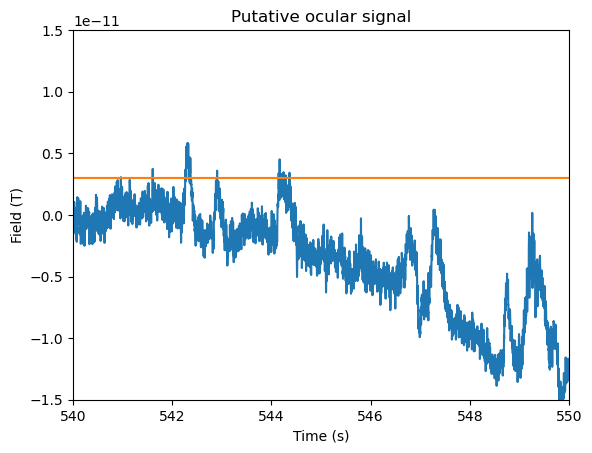

In [8]:
tr = np.full(len(occ_signal), 0.3e-11)  # threshold line (0.3e-11 T = 3000 fT)
plt.plot(raw.times, occ_signal, raw.times, tr)
plt.xlim(540, 550); plt.ylim(-1.5e-11, 1.5e-11)
plt.xlabel('Time (s)'); plt.ylabel('Field (T)'); plt.title('Putative ocular signal')

Two eye-blinks are clearly visible. The orange line denotes the threshold which is set to 0.3e-11 T.

Subsequently use the MNE-defined function to identify the ocular events:

In [9]:
eog_events = mne.preprocessing.find_eog_events(raw, ch_name='OCC',thresh=0.3e-11) 

Using EOG channel: OCC
EOG channel index for this subject is: [170]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel OCC for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 7500 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 1566 significant peaks
Number of EOG events detected: 1566


In total, 721 events were identified as blinks. To store these on the dataset, the next step is to create an annotation object holding, for each blink, the onset (250 ms before the crossing), the duration (0.5 s), and a description label (i.e. tag) identifying the type of event:

In [10]:
n_blinks = len(eog_events)
onset = eog_events[:, 0] / raw.info['sfreq'] - 0.25
duration = np.repeat(0.5, n_blinks)
description = ['blink'] * n_blinks
orig_time = raw.info['meas_date']
annotations_blink = mne.Annotations(onset, duration, description, orig_time)

**Question 1** Discuss the pros and cons of using a fixed amplitude threshold for ocular artefacts, compared with a statistical measure such as one based on z-scores.

## Detecting muscle artefacts

Muscle artefacts typically appear as high-frequency signals reflecting magnetomyographic muscle contractions [1]. Here they are identified from the magnetometer data filtered in the 110–140 Hz range. The filtered data are then z-scored, and whenever the z-score exceeds 3, the corresponding section of data is annotated as a muscle artefact. The shortest allowed stretch of "good" data between adjacent annotations is 0.1 s; shorter gaps are absorbed into the surrounding annotations.

Before computing the Z-score make sure the 'bad' channels are removed.

In [11]:
raw_clean = raw.copy().drop_channels(raw.info['bads'])

Compute the Z-score

In [12]:
threshold_muscle = 3
annotations_muscle, scores_muscle = annotate_muscle_zscore(
    raw_clean, ch_type="mag", threshold=threshold_muscle, min_length_good=0.1,
    filter_freq=[110, 140])


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1.1e+02 - 1.4e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 110.00
- Lower transition bandwidth: 27.50 Hz (-6 dB cutoff frequency: 96.25 Hz)
- Upper passband edge: 140.00 Hz
- Upper transition bandwidth: 35.00 Hz (-6 dB cutoff frequency: 157.50 Hz)
- Filter length: 91 samples (0.121 s)

Setting up low-pass filter at 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 1239 samples (1.652 s)



Muscle artefacts identified:

In [13]:
print(annotations_muscle)

<Annotations | 49 segments: BAD_muscle (49)>


To check whether the threshold used for the muscle annotation is appropriate, plot the z-scores as a function of time. The threshold (z = 3) is indicated by a red line.

Text(0.5, 1.0, 'Putative muscular activity')

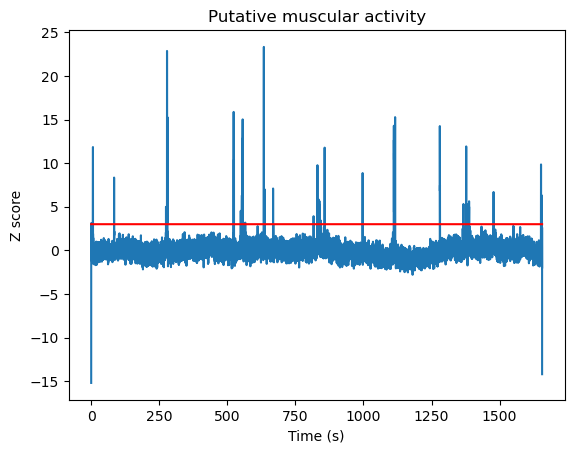

In [14]:
tr = np.full(len(scores_muscle), threshold_muscle)  # threshold line at z = 3
plt.plot(raw_clean.times, scores_muscle)
plt.plot(raw_clean.times, tr, color='r')
plt.xlabel('Time (s)'); plt.ylabel('Z score'); plt.title('Putative muscular activity')

## Include annotations in dataset and inspect visually

Now mark all the annotations in the data set.

Since calling set_annotations() replaces any existing annotations in the Raw object, the original annotations are first extracted and then combined with the blink and muscle annotations before being reassigned.

In [15]:
annotations_event = raw.annotations 
raw_clean.set_annotations(annotations_event + annotations_blink + annotations_muscle)

/var/folders/n0/w7vb4jpn0nx3hs95f4p7r9br0000gr/T/ipykernel_55536/2036331298.py:2: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_clean.set_annotations(annotations_event + annotations_blink + annotations_muscle)


<Raw | sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif, 171 x 1241952 (1655.9 s), ~1.58 GiB, data loaded>

To inspect the annotations visually write

In [16]:
%matplotlib inline
raw_clean.plot(start=50);

Using qt as 2D backend.
Channels marked as bad:
none


To inspect the ocular artefacts specifically, display the `OCC` channel created earlier (use the **+** button to increase the gain if the signal is not clearly visible):

In [18]:
eog_picks=mne.pick_types(raw_clean.info,meg=False,eog=True)
raw_clean.plot(order=eog_picks,start=50,duration=10,scalings=dict(eog=0.2e-10));

### Save the artefact annotations

Save the annotations in a file to be used in the subsequent sections:

In [17]:
raw_clean.save(deriv_fname_fif, overwrite=True)
raw_clean.annotations.save(deriv_fname_csv, overwrite=True)

Writing /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.fif
Closing /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.fif
[done]


## Preregistration and Publication

A preregistration should specify how artefacts are detected and annotated in enough detail to be reproduced exactly. Note that at this stage artefacts are only *annotated*, not rejected; the annotations are used later to decide which trials to exclude. We recommend committing to the following in advance:

**Ocular artefacts**
- The channels used to form the surrogate ocular signal (here the difference F9 A4 Z − F10 B3 Z) and the band-pass filter (1–10 Hz).
- The detection threshold and how it is set: here a fixed amplitude of 0.3e-11 T (3000 fT), chosen by visual inspection. State whether the threshold is fixed a priori or data-driven (see Question 1).
- The annotated window around each blink (here 500 ms, from −250 to +250 ms).

**Muscle artefacts**
- The sensor type (magnetometers), the band-pass filter (110–140 Hz), and the metric (z-score of the filtered envelope) [1].
- The z-score threshold (here 3) and the minimum length of good data between annotations (here 0.1 s).
- That noisy/bad sensors are excluded before computing the z-score.

**General**
- Software and versions (MNE-Python, MNE-BIDS), since defaults may change between releases.
- Where the annotated data and annotations are stored (BIDS `derivatives`, `*_ann_raw.fif` / `*_ann_raw.csv`).
- Pre-specify all thresholds rather than tuning them post hoc, and distinguish confirmatory from exploratory choices.

**Example preregistration / methods text**

> "Artefacts were annotated so that affected epochs could later be rejected. Ocular artefacts were identified by subtracting the signal of a right frontal sensor from a left frontal sensor (F9 A4 Z − F10 B3 Z) and band-pass filtering the result to 1–10 Hz. When the absolute difference exceeded 3000 fT, the event was considered an eye blink and the data ±250 ms around it were annotated. Muscle artefacts were identified from the magnetometer data band-pass filtered to 110–140 Hz [1]; the filtered signal was z-scored, and segments exceeding a z-score of 3 were annotated as muscle artefacts (minimum 0.1 s of good data between annotations). All processing was performed in MNE-Python (version X.X)."

## References

[1] Muthukumaraswamy, S. (2013). *High-frequency brain activity and muscle artifacts in MEG/EEG: a review and recommendations*. *Frontiers in Human Neuroscience*, **7**, 138. [https://doi.org/10.3389/fnhum.2013.00138](https://doi.org/10.3389/fnhum.2013.00138)

